# Phase 2b — Longformer Baseline (PERSUADE 2.0)

A second transformer baseline for automated holistic essay scoring, trained under the same experimental conditions as the Phase 2 BERT baseline.

The BERT baseline was constrained to a 512-token window, which required a head-and-tail truncation strategy to fit longer essays. Longformer replaces the full self-attention mechanism with a combination of local sliding-window attention and task-specific global attention, allowing the model to process substantially longer sequences at manageable memory cost. This baseline evaluates whether processing essays without aggressive truncation changes holistic scoring behaviour on the same corpus.

To keep the comparison meaningful, the data split, score normalisation, loss function, optimiser configuration, and evaluation protocol are held identical to the BERT run. Only the components that must differ for Longformer are changed: the tokeniser, the maximum sequence length, the global-attention specification, and the memory-management settings.

**Reference:** Beltagy, Peters and Cohan (2020), *Longformer: The Long-Document Transformer*.

---

**Reproducibility settings**
- Model: `allenai/longformer-base-4096`
- Maximum sequence length: 1024 tokens
- Split seed: `random_state=42` (identical to BERT)
- Effective batch size: 16 (batch 4 x gradient accumulation 4)
- Epochs: 4 | Learning rate: 2e-5 | Weight decay: 0.01

## 1. Environment

Session requirements on Kaggle: a GPU accelerator (P100 recommended) and internet access enabled, the latter to retrieve the pretrained Longformer weights on first use.

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from transformers import LongformerModel, LongformerTokenizerFast
from transformers import get_linear_schedule_with_warmup
from transformers import logging as hf_logging
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, time, json

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
if device.type == 'cuda':
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4
GPU memory      : 15.6 GB


## 2. Data preparation and stratified split

The corpus is loaded, deduplicated on `essay_id`, and split into training, validation, and test partitions. A stratification key combining prompt name and holistic score preserves the joint distribution of prompt and grade across partitions; strata with fewer than four essays are dropped so that stratified sampling remains valid.

This block reproduces the Phase 2 split exactly. The seed and split proportions are unchanged, so the three partitions contain the same essays used to train and evaluate BERT. Identical partitions are a precondition for attributing any difference in results to the model rather than to the data.

In [6]:
DATA_PATH = '/kaggle/input/datasets/shravaniuk/persuade-corpus-2-0-tarin-test-longformer'

df_raw = pd.read_csv(f'{DATA_PATH}/persuade_corpus_2.0_train.csv')

KEEP_COLS = ['essay_id', 'full_text', 'holistic_essay_score',
             'prompt_name', 'grade_level', 'gender',
             'race_ethnicity', 'ell_status',
             'student_disability_status', 'economically_disadvantaged', 'task']

df = (df_raw[KEEP_COLS]
        .drop_duplicates(subset='essay_id')
        .reset_index(drop=True))

df['strat_key'] = df['prompt_name'].str.replace(' ', '_') + '_' + df['holistic_essay_score'].astype(str)
key_counts = df['strat_key'].value_counts()
valid_keys = key_counts[key_counts >= 4].index
df_valid   = df[df['strat_key'].isin(valid_keys)].copy()

df_train, df_temp = train_test_split(df_valid, test_size=0.20,
                                     random_state=42, stratify=df_valid['strat_key'])
df_val, df_test = train_test_split(df_temp, test_size=0.50,
                                   random_state=42, stratify=None)

for split in [df_train, df_val, df_test]:
    split.drop(columns=['strat_key'], inplace=True)

print(f"Train : {len(df_train):,} essays")
print(f"Val   : {len(df_val):,} essays")
print(f"Test  : {len(df_test):,} essays")
print(f"Score range : {int(df['holistic_essay_score'].min())} to {int(df['holistic_essay_score'].max())}")

Train : 12,464 essays
Val   : 1,558 essays
Test  : 1,559 essays
Score range : 1 to 6


The printed partition sizes should read 12,464 / 1,558 / 1,559, matching the Phase 2 baseline. If they differ, the split has diverged and the comparison is no longer controlled.

## 3. Tokenisation and dataset

Longformer processes the essay as a single sequence up to `MAX_LEN` tokens, so the head-and-tail truncation used for BERT is not required. A maximum length of 1024 covers the large majority of essays in full and is a multiple of Longformer's 512-token attention window, which avoids internal re-padding.

Each example carries a global-attention mask with a single active position on the leading `<s>` token. That token attends to, and is attended by, the entire sequence and serves as the pooled representation passed to the regression head; all remaining positions use local sliding-window attention.

Holistic scores are mapped to the unit interval with `(score - 1) / 5`, matching the target scaling used for BERT.

In [7]:
MODEL_NAME = 'allenai/longformer-base-4096'
MAX_LEN    = 1024

tokenizer = LongformerTokenizerFast.from_pretrained(MODEL_NAME)


class EssayDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=MAX_LEN):
        self.texts  = dataframe['full_text'].tolist()
        self.scores = dataframe['holistic_essay_score'].tolist()
        self.ids    = dataframe['essay_id'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids      = enc['input_ids'].squeeze(0)
        attention_mask = enc['attention_mask'].squeeze(0)

        global_attention_mask = torch.zeros_like(attention_mask)
        global_attention_mask[0] = 1                       # global attention on <s>

        label = torch.tensor((self.scores[idx] - 1) / 5.0, dtype=torch.float)

        return {
            'input_ids':             input_ids,
            'attention_mask':        attention_mask,
            'global_attention_mask': global_attention_mask,
            'label':                 label,
            'score':                 torch.tensor(self.scores[idx], dtype=torch.long)
        }


BATCH_SIZE  = 4
NUM_WORKERS = 2

train_dataset = EssayDataset(df_train, tokenizer)
val_dataset   = EssayDataset(df_val,   tokenizer)
test_dataset  = EssayDataset(df_test,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Tokenizer     : {MODEL_NAME}")
print(f"Max length    : {MAX_LEN} tokens")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Tokenizer     : allenai/longformer-base-4096
Max length    : 1024 tokens
Train batches : 3116
Val batches   : 390
Test batches  : 390


## 4. Model

The scoring model is Longformer with a linear regression head over the pooled `<s>` representation. Dropout of 0.3 is applied before the head. This mirrors the BERT scorer, where the difference is the encoder alone. Gradient checkpointing is enabled to reduce activation memory, which allows the 1024-token sequence length to fit within a single-GPU session.

In [8]:
class LongformerEssayScorer(nn.Module):
    def __init__(self, model_name=MODEL_NAME, dropout=0.3):
        super().__init__()
        self.longformer = LongformerModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(dropout)
        self.regressor  = nn.Linear(self.longformer.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask, global_attention_mask):
        outputs = self.longformer(
            input_ids=input_ids,
            attention_mask=attention_mask,
            global_attention_mask=global_attention_mask
        )
        cls_output = outputs.last_hidden_state[:, 0, :]     # <s> token
        dropped    = self.dropout(cls_output)
        return self.regressor(dropped).squeeze(-1)


model = LongformerEssayScorer().to(device)
model.longformer.gradient_checkpointing_enable()

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Architecture         : Longformer-base + linear regression head")
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Hidden size          : {model.longformer.config.hidden_size}")
print(f"Attention window     : {model.longformer.config.attention_window[0]}")

Loading weights:   0%|          | 0/271 [00:00<?, ?it/s]

Architecture         : Longformer-base + linear regression head
Total parameters     : 148,660,225
Trainable parameters : 148,660,225
Hidden size          : 768
Attention window     : 512


## 5. Optimisation configuration

Training uses AdamW with a learning rate of 2e-5, weight decay of 0.01, and a linear schedule with 10% warmup, over four epochs. These settings match the BERT run.

Two adjustments accommodate Longformer's higher memory footprint without altering the effective optimisation signal. Gradient accumulation over four micro-batches of size 4 yields an effective batch size of 16, equal to BERT's batch size. Automatic mixed precision reduces memory use and shortens epoch time. The scheduler is stepped once per optimiser update rather than once per micro-batch, so the total number of scheduled steps reflects the effective batch size.

In [9]:
EPOCHS       = 4
LR           = 2e-5
WARMUP_RATIO = 0.1
ACCUM_STEPS  = 4                                   # effective batch = 4 x 4 = 16

total_steps  = (len(train_loader) // ACCUM_STEPS) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
loss_fn = nn.MSELoss()
scaler  = GradScaler()

print(f"Epochs           : {EPOCHS}")
print(f"Learning rate    : {LR}")
print(f"Effective batch  : {BATCH_SIZE * ACCUM_STEPS}")
print(f"Optimiser steps  : {total_steps}")
print(f"Warmup steps     : {warmup_steps}")
print(f"Loss             : MSE on normalised [0, 1] targets")

Epochs           : 4
Learning rate    : 2e-05
Effective batch  : 16
Optimiser steps  : 3116
Warmup steps     : 311
Loss             : MSE on normalised [0, 1] targets


## 6. Evaluation functions

The primary metric is quadratic weighted kappa (QWK), consistent with the Phase 2 evaluation and the wider automated-scoring literature. Continuous predictions are returned to the original 1-6 scale with `round(pred * 5 + 1)` and clipped to the valid range before computing QWK, mean absolute error, and exact accuracy. The denormalisation is identical to the BERT pipeline, so the two models are scored on the same footing.

In [10]:
def compute_qwk(model, loader, device):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in loader:
            with autocast():
                out = model(batch['input_ids'].to(device),
                            batch['attention_mask'].to(device),
                            batch['global_attention_mask'].to(device))
            pred = np.clip(np.round(out.float().cpu().numpy() * 5 + 1).astype(int), 1, 6)
            preds.extend(pred.tolist())
            labels.extend(batch['score'].numpy().tolist())
    return cohen_kappa_score(labels, preds, weights='quadratic')


def run_validation(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            with autocast():
                out  = model(batch['input_ids'].to(device),
                             batch['attention_mask'].to(device),
                             batch['global_attention_mask'].to(device))
                loss = loss_fn(out, batch['label'].to(device))
            total_loss += loss.item()
    return total_loss / len(loader)

print("Evaluation functions defined.")
print("Denormalisation: round(pred * 5 + 1), clipped to [1, 6].")

Evaluation functions defined.
Denormalisation: round(pred * 5 + 1), clipped to [1, 6].


## 7. Training

The training loop accumulates gradients over four micro-batches before each optimiser step, applies gradient clipping at a norm of 1.0, and steps the learning-rate schedule once per update. Validation loss and QWK are computed at the end of every epoch, and the checkpoint achieving the highest validation QWK is retained for final evaluation.

At 1024 tokens with mixed precision, a full epoch takes roughly 30 to 60 minutes on a P100. If the session approaches its time limit, reducing the maximum length or the number of epochs is acceptable, provided the change is recorded.

In [11]:
train_losses, val_losses, val_qwks = [], [], []
best_qwk, best_epoch = 0.0, 0

print("Longformer fine-tuning")
print(f"Target QWK: 0.75")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()
    start_time = time.time()

    for step, batch in enumerate(train_loader):
        with autocast():
            out  = model(batch['input_ids'].to(device),
                         batch['attention_mask'].to(device),
                         batch['global_attention_mask'].to(device))
            loss = loss_fn(out, batch['label'].to(device)) / ACCUM_STEPS

        scaler.scale(loss).backward()
        running_loss += loss.item() * ACCUM_STEPS

        if (step + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        if (step + 1) % 200 == 0:
            avg = running_loss / (step + 1)
            elapsed = time.time() - start_time
            print(f"  Epoch {epoch} | Step {step+1}/{len(train_loader)} | "
                  f"Loss {avg:.4f} | Time {elapsed:.0f}s")

    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss   = run_validation(model, val_loader, loss_fn, device)
    val_qwk        = compute_qwk(model, val_loader, device)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_qwks.append(val_qwk)

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss {avg_train_loss:.4f} | "
          f"Val Loss {avg_val_loss:.4f} | Val QWK {val_qwk:.4f} | {epoch_time:.0f}s")

    if val_qwk > best_qwk:
        best_qwk, best_epoch = val_qwk, epoch
        torch.save(model.state_dict(), 'best_longformer_aes_model.pt')
        print(f"  Best checkpoint saved (Val QWK {best_qwk:.4f})")

Longformer fine-tuning
Target QWK: 0.75
-------------------------------------------------------
  Epoch 1 | Step 200/3116 | Loss 0.1674 | Time 200s
  Epoch 1 | Step 400/3116 | Loss 0.1173 | Time 402s
  Epoch 1 | Step 600/3116 | Loss 0.0944 | Time 604s
  Epoch 1 | Step 800/3116 | Loss 0.0807 | Time 807s
  Epoch 1 | Step 1000/3116 | Loss 0.0713 | Time 1010s
  Epoch 1 | Step 1200/3116 | Loss 0.0645 | Time 1213s
  Epoch 1 | Step 1400/3116 | Loss 0.0591 | Time 1416s
  Epoch 1 | Step 1600/3116 | Loss 0.0546 | Time 1619s
  Epoch 1 | Step 1800/3116 | Loss 0.0512 | Time 1822s
  Epoch 1 | Step 2000/3116 | Loss 0.0483 | Time 2024s
  Epoch 1 | Step 2200/3116 | Loss 0.0462 | Time 2227s
  Epoch 1 | Step 2400/3116 | Loss 0.0441 | Time 2430s
  Epoch 1 | Step 2600/3116 | Loss 0.0422 | Time 2633s
  Epoch 1 | Step 2800/3116 | Loss 0.0406 | Time 2836s
  Epoch 1 | Step 3000/3116 | Loss 0.0396 | Time 3039s
Epoch 1/4 | Train Loss 0.0390 | Val Loss 0.0326 | Val QWK 0.7306 | 3453s
  Best checkpoint saved (Val 

### Training summary

In [12]:
print("Training history")
print(f"{'Epoch':<8}{'Train Loss':<14}{'Val Loss':<12}{'Val QWK':<10}{'Best'}")
print("-" * 52)
for ep in range(EPOCHS):
    marker = "best" if (ep + 1) == best_epoch else ""
    print(f"{ep+1:<8}{train_losses[ep]:<14.4f}{val_losses[ep]:<12.4f}{val_qwks[ep]:<10.4f}{marker}")
print()
print(f"Best validation QWK : {best_qwk:.4f} (epoch {best_epoch})")

Training history
Epoch   Train Loss    Val Loss    Val QWK   Best
----------------------------------------------------
1       0.0390        0.0326      0.7306    
2       0.0174        0.0130      0.8175    
3       0.0131        0.0126      0.8365    
4       0.0106        0.0112      0.8520    best

Best validation QWK : 0.8520 (epoch 4)


## 8. Test-set evaluation

The best checkpoint is reloaded and evaluated once on the held-out test partition. Alongside QWK, the report includes mean absolute error, exact-match accuracy, and adjacent accuracy (predictions within one score band), the last of which is a standard companion to QWK in the scoring literature. The BERT baseline result is printed for reference.

In [13]:
model.load_state_dict(torch.load('best_longformer_aes_model.pt', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        with autocast():
            out = model(batch['input_ids'].to(device),
                        batch['attention_mask'].to(device),
                        batch['global_attention_mask'].to(device))
        pred = np.clip(np.round(out.float().cpu().numpy() * 5 + 1).astype(int), 1, 6)
        all_preds.extend(pred.tolist())
        all_labels.extend(batch['score'].numpy().tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
mae      = np.mean(np.abs(all_preds - all_labels))
accuracy = np.mean(all_preds == all_labels)
adj_acc  = np.mean(np.abs(all_preds - all_labels) <= 1)

print("=" * 50)
print("LONGFORMER — TEST SET RESULTS")
print("=" * 50)
print(f"Test QWK (primary)   : {test_qwk:.4f}")
print(f"Mean absolute error  : {mae:.4f}")
print(f"Exact accuracy       : {accuracy:.4f}")
print(f"Adjacent accuracy    : {adj_acc:.4f}")
print(f"Essays evaluated     : {len(all_labels)}")
print("-" * 50)
print(f"Spec target QWK >= 0.75 : {'met' if test_qwk >= 0.75 else 'not met'}")
print(f"BERT baseline QWK       : 0.8283")
print("=" * 50)

LONGFORMER — TEST SET RESULTS
Test QWK (primary)   : 0.8555
Mean absolute error  : 0.3355
Exact accuracy       : 0.6754
Adjacent accuracy    : 0.9897
Essays evaluated     : 1559
--------------------------------------------------
Spec target QWK >= 0.75 : met
BERT baseline QWK       : 0.8283


### Per-class breakdown

In [14]:
print("Per-class performance")
print("-" * 55)
print(classification_report(
    all_labels, all_preds,
    labels=[1, 2, 3, 4, 5, 6],
    target_names=[f'Score {i}' for i in range(1, 7)],
    digits=4, zero_division=0
))

Per-class performance
-------------------------------------------------------
              precision    recall  f1-score   support

     Score 1     0.8667    0.2063    0.3333        63
     Score 2     0.7123    0.6541    0.6820       318
     Score 3     0.6750    0.7018    0.6881       503
     Score 4     0.6490    0.7380    0.6907       416
     Score 5     0.6542    0.6897    0.6715       203
     Score 6     0.7619    0.5714    0.6531        56

    accuracy                         0.6754      1559
   macro avg     0.7199    0.5935    0.6198      1559
weighted avg     0.6838    0.6754    0.6698      1559



## 9. Outputs

The trained weights, a results summary, essay-level predictions, and diagnostic figures are written to the working directory. The weights file supports a later robustness comparison in which the Phase 3 perturbation audit is repeated with Longformer in place of BERT.

In [15]:
results = {
    'model'            : MODEL_NAME,
    'dataset'          : 'PERSUADE 2.0',
    'max_len'          : MAX_LEN,
    'effective_batch'  : BATCH_SIZE * ACCUM_STEPS,
    'train_essays'     : len(df_train),
    'val_essays'       : len(df_val),
    'test_essays'      : len(df_test),
    'epochs'           : EPOCHS,
    'best_epoch'       : best_epoch,
    'best_val_qwk'     : round(best_qwk, 4),
    'test_qwk'         : round(float(test_qwk), 4),
    'test_mae'         : round(float(mae), 4),
    'test_accuracy'    : round(float(accuracy), 4),
    'adjacent_accuracy': round(float(adj_acc), 4),
    'train_losses'     : [round(x, 4) for x in train_losses],
    'val_losses'       : [round(x, 4) for x in val_losses],
    'val_qwks'         : [round(x, 4) for x in val_qwks],
    'bert_test_qwk'    : 0.8283,
    'target_qwk'       : 0.75,
    'target_met'       : bool(test_qwk >= 0.75)
}

with open('longformer_results.json', 'w') as f:
    json.dump(results, f, indent=2)

pred_df = pd.DataFrame({
    'essay_id'  : df_test['essay_id'].values,
    'true_score': all_labels,
    'pred_score': all_preds,
    'error'     : np.abs(all_labels - all_preds)
})
pred_df.to_csv('test_predictions_longformer.csv', index=False)

print("Saved:")
print("  best_longformer_aes_model.pt")
print("  longformer_results.json")
print("  test_predictions_longformer.csv")

Saved:
  best_longformer_aes_model.pt
  longformer_results.json
  test_predictions_longformer.csv


### Diagnostic figures

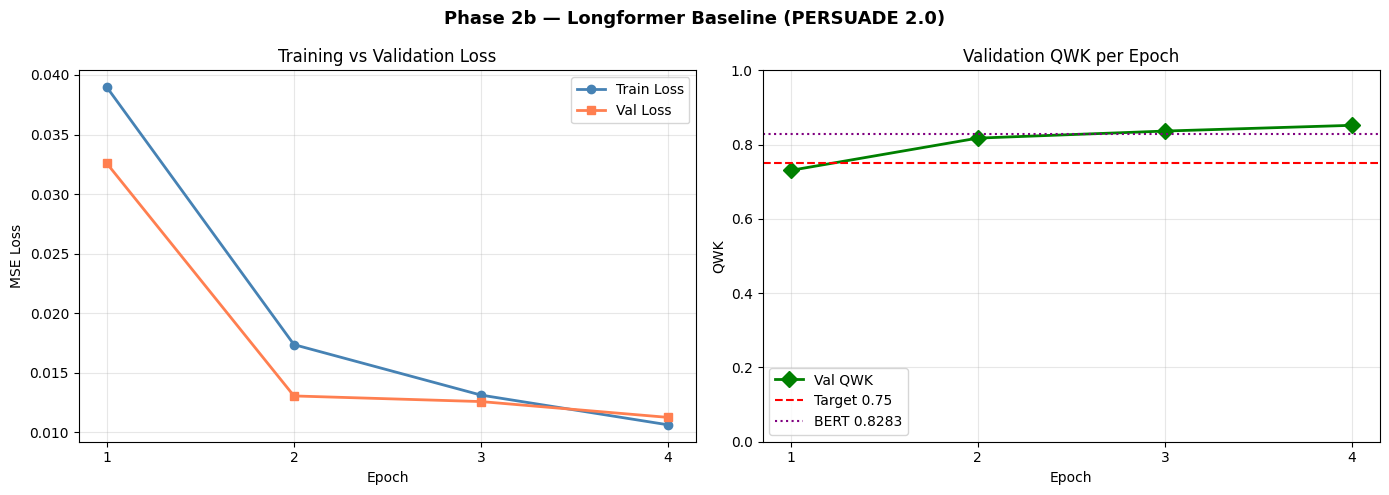

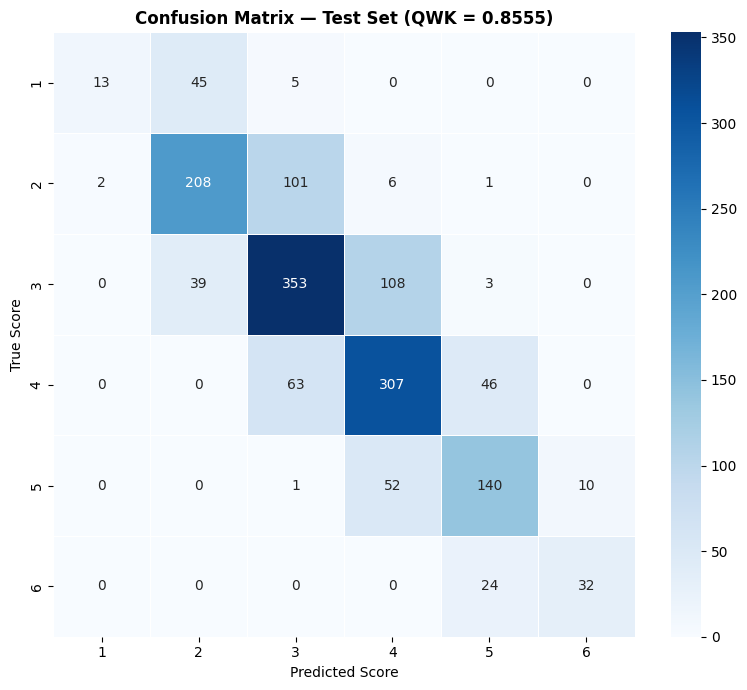

Saved: fig_longformer_training.png, fig_longformer_confusion.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, train_losses, 'o-', label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(epochs_range, val_losses,   's-', label='Val Loss',   color='coral',     linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xticks(list(epochs_range)); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, val_qwks, 'D-', color='green', linewidth=2, markersize=8, label='Val QWK')
axes[1].axhline(0.75,   color='red',    linestyle='--', linewidth=1.5, label='Target 0.75')
axes[1].axhline(0.8283, color='purple', linestyle=':',  linewidth=1.5, label='BERT 0.8283')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('QWK')
axes[1].set_title('Validation QWK per Epoch')
axes[1].set_xticks(list(epochs_range)); axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Phase 2b — Longformer Baseline (PERSUADE 2.0)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_longformer_training.png', dpi=150, bbox_inches='tight')
plt.show()


cm = confusion_matrix(all_labels, all_preds, labels=[1, 2, 3, 4, 5, 6])
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1, 2, 3, 4, 5, 6], yticklabels=[1, 2, 3, 4, 5, 6],
            ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted Score'); ax.set_ylabel('True Score')
ax.set_title(f'Confusion Matrix — Test Set (QWK = {test_qwk:.4f})', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_longformer_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: fig_longformer_training.png, fig_longformer_confusion.png")

## 10. Checkpoint verification

A final check reloads the saved weights and runs a single test batch to confirm the checkpoint is intact and ready for downstream use in the robustness audit.

In [17]:
verify_model = LongformerEssayScorer().to(device)
verify_model.load_state_dict(torch.load('best_longformer_aes_model.pt', map_location=device))
verify_model.eval()

with torch.no_grad():
    batch = next(iter(test_loader))
    with autocast():
        out = verify_model(batch['input_ids'].to(device),
                           batch['attention_mask'].to(device),
                           batch['global_attention_mask'].to(device))
    pred = np.clip(np.round(out.float().cpu().numpy() * 5 + 1).astype(int), 1, 6)

print("Checkpoint reload verified.")
print(f"Sample predictions: {pred[:8].tolist()}")

Loading weights:   0%|          | 0/271 [00:00<?, ?it/s]

Checkpoint reload verified.
Sample predictions: [3, 4, 4, 4]


## Summary

Longformer was trained as a second holistic-scoring baseline under conditions matched to the Phase 2 BERT run: the same corpus partitions, target scaling, loss, optimiser, effective batch size, and evaluation protocol. The distinguishing factor is the encoder's capacity to read full essays at 1024 tokens without head-and-tail truncation.

The saved checkpoint enables a like-for-like robustness comparison in which the Phase 3 perturbation audit is repeated with Longformer, isolating the effect of the encoder on sensitivity to the P1-P6 perturbations.